In [1]:
import os
import sys
sys.path.append("../../")

from biked_commons.design_evaluation.design_evaluation import *
from biked_commons.conditioning import conditioning
from biked_commons.resource_utils import datasets_path
from biked_commons.benchmark_models import benchmarking_utils
from biked_commons.benchmark_models.generative_modeling_utils import sample_continuous
from biked_commons.design_evaluation.score_report import ScoreReportDashboard

c:\Users\Lyler\mambaforge\envs\bike-bench-cuda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model scores are calcualted after model training, but in case the evaluation functions change, the following funcitons can be used to rescore all models in the result folders

In [2]:
# data = data_loading.load_bike_bench_train()
# benchmarking_utils.rescore_unconditional(data.columns, device="cuda")
# benchmarking_utils.rescore_conditional(data.columns, device="cuda")


## Main Scores

Score report for coniditonal generation:

In [3]:
import importlib
importlib.reload(benchmarking_utils)
conditional_scores = benchmarking_utils.create_score_report_conditional()
#turn constraint satisfaction rate into a percent with two decimal places
conditional_scores['Constraint Satisfaction Rate'] = conditional_scores['Constraint Satisfaction Rate'] * 100
conditional_scores['Constraint Satisfaction Rate'] = conditional_scores['Constraint Satisfaction Rate'].apply(lambda x: "{:.2f}%".format(x))

#four decimals for Hypervolume and Maximum Mean Discrepancy
conditional_scores['Hypervolume'] = conditional_scores['Hypervolume'].apply(lambda x: "{:.4f}".format(x))
conditional_scores['Maximum Mean Discrepancy'] = conditional_scores['Maximum Mean Discrepancy'].apply(lambda x: "{:.4f}".format(x))


savedir = os.path.join("results", "cond_overall_scores.csv")
conditional_scores.to_csv(savedir, index=False)
display(conditional_scores)



,Constraint Satisfaction Rate,Hypervolume,Maximum Mean Discrepancy
CTGAN,0.37%,0.2062,0.0376
DDPM_conditional,38.76%,0.2643,0.0295
DDPM_conditional-CI,17.44%,0.2506,0.0316
DDPM_guided,28.70%,0.2629,0.0346
DDPM_guided-CI,14.03%,0.2372,0.0359
Dataset,1.18%,0.2834,0.0007
GAN,27.32%,0.2133,0.0941
GAN-CI,16.90%,0.2190,0.1474
O4-mini,0.54%,0.2009,0.3140
TVAE,0.00%,0.0000,0.0358


Score report for unconditional generation:

In [4]:
pd.set_option('display.max_rows', 100)
unconditional_scores = benchmarking_utils.create_score_report_unconditional()
#turn constraint satisfaction rate into a percent with two decimal places
unconditional_scores['Constraint Satisfaction Rate'] = unconditional_scores['Constraint Satisfaction Rate'] * 100
unconditional_scores['Constraint Satisfaction Rate'] = unconditional_scores['Constraint Satisfaction Rate'].apply(lambda x: "{:.2f}%".format(x))

#four decimals for Hypervolume and Maximum Mean Discrepancy
unconditional_scores['Hypervolume'] = unconditional_scores['Hypervolume'].apply(lambda x: "{:.4f}".format(x))
unconditional_scores['Maximum Mean Discrepancy'] = unconditional_scores['Maximum Mean Discrepancy'].apply(lambda x: "{:.4f}".format(x))

savedir = os.path.join("results", "uncond_overall_scores.csv")
unconditional_scores.to_csv(savedir, index=False)
display(unconditional_scores)


,Constraint Satisfaction Rate,Hypervolume,Maximum Mean Discrepancy
Agg-LS,93.82%,0.2817,0.5668
Agg-LS-CI,6.00%,0.0759,0.5462
CTGAN,0.21%,0.0630,0.0283
DDPM_conditional,33.10%,0.1672,0.0403
DDPM_conditional-CI,14.84%,0.1604,0.0417
DDPM_guided,30.46%,0.1697,0.0353
DDPM_guided-CI,16.22%,0.1656,0.0344
Dataset,1.00%,0.1560,0.0007
GAN,33.28%,0.1324,0.1741
GAN-CI,15.68%,0.1066,0.3056


## Score Scatterplots

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

def plot_scores(
    scores_subset,
    zoom_hv=(0.13, 0.175),
    zoom_mmd=(0.033, 0.063),
    cmap_name='cividis_r',
    marker_map=None,
    show_ci="Both",
    text_offset=8,
    axis_fontsize=14,
    legend_fontsize=13,
    cbar_fontsize=14,
    legend_loc = 'center right'
):
    """
    Scatter + zoom plot of model scores with optional CI models and custom annotation locations.

    Parameters
    ----------
    scores_subset : pd.DataFrame
        Indexed by model name, with columns:
        - 'Constraint Satisfaction Rate' (e.g. "93.82%")
        - 'Hypervolume' (float)
        - 'Maximum Mean Discrepancy' (float)
        - 'class' (str)
        - 'annotation_location' (str): one of 'top', 'left'
    zoom_hv : tuple(float, float)
    zoom_mmd : tuple(float, float)
    cmap_name : str
    marker_map : dict or None
    show_ci : bool
    text_offset : float
    axis_fontsize, legend_fontsize, cbar_fontsize : int
    """
    # 1) Prepare DataFrame
    df = scores_subset.copy()
    df['Hypervolume'] = df['Hypervolume'].astype(float)
    df['Maximum Mean Discrepancy'] = df['Maximum Mean Discrepancy'].astype(float)
    df['CSR'] = df['Constraint Satisfaction Rate'].str.rstrip('%').astype(float)

    # 2) Optionally drop CI rows
    if show_ci == "CI":
        # Find base models that have corresponding '-CI' versions
        ci_suffix = '-CI'
        base_models_with_ci = {
            nm[:-len(ci_suffix)]
            for nm in df.index
            if nm.endswith(ci_suffix) and (nm[:-len(ci_suffix)] in df.index)
        }

        # Drop those base models (but keep CI versions)
        df = df[~df.index.isin(base_models_with_ci)]
        
    elif show_ci == "Base":
        df = df[~df.index.str.endswith('-CI')]

    # 3) Marker mapping
    default_map = {'Opt':'o','Data':'s','LLM':'D','TGM':'^','OAGM':'v'}
    marker_map = marker_map or default_map
    df['marker'] = df['class'].map(marker_map)


    # 4) Identify CI connectors
    ci_pairs = []
    if show_ci == "Both":
        ci_pairs = [
            (nm[:-3], nm)
            for nm in df.index
            if nm.endswith('-CI') and (nm[:-3] in df.index)
        ]

    # 5) Plot settings
    ms = 100
    cmap = plt.get_cmap(cmap_name)
    inside = (
        (df['Hypervolume'] >= zoom_hv[0]) & (df['Hypervolume'] <= zoom_hv[1]) &
        (df['Maximum Mean Discrepancy'] >= zoom_mmd[0]) & (df['Maximum Mean Discrepancy'] <= zoom_mmd[1])
    )

    # Helper to compute annotation parameters
    def get_annot_params(loc):
        if loc == 'left':
            return {'xytext':(-text_offset, 0), 'ha':'right', 'va':'center'}
        elif loc == 'right':
            return {'xytext':(text_offset, 0), 'ha':'left', 'va':'center'}
        # default to top
        return {'xytext':(0, text_offset), 'ha':'center', 'va':'bottom'}

    # 6) Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

    # Main scatter + connectors
    for cls, grp in df.groupby('class'):
        ax1.scatter(
            grp['Hypervolume'], grp['Maximum Mean Discrepancy'],
            c=grp['CSR'], cmap=cmap,
            vmin=df['CSR'].min(), vmax=df['CSR'].max(),
            marker=marker_map.get(cls, 'o'), s=ms, alpha=0.8,
            edgecolor='k', linewidth=0.5
        )
    for base, ci in ci_pairs:
        ax1.plot(
            [df.at[base, 'Hypervolume'], df.at[ci, 'Hypervolume']],
            [df.at[base, 'Maximum Mean Discrepancy'], df.at[ci, 'Maximum Mean Discrepancy']],
            linestyle=':', color='gray'
        )

    # Highlight rectangle + label
    rect = Rectangle(
        (zoom_hv[0], zoom_mmd[0]),
        zoom_hv[1] - zoom_hv[0], zoom_mmd[1] - zoom_mmd[0],
        edgecolor='gray', facecolor='none', linestyle='--', linewidth=1.2
    )
    ax1.add_patch(rect)
    x_center = (zoom_hv[0] + zoom_hv[1]) / 2
    ax1.text(
        x_center, zoom_mmd[1] + 0.005, "Highlight:",
        ha='center', va='bottom', fontsize=axis_fontsize, fontweight='bold'
    )

    # Annotate outside-zoom points with custom locations
    for nm, row in df[~inside].iterrows():
        params = get_annot_params(row.get('annotation_location', 'top'))
        ax1.annotate(
            f"{nm}\n({row['CSR']:.1f}%)",
            (row['Hypervolume'], row['Maximum Mean Discrepancy']),
            textcoords='offset points',
            **params,
            fontsize=axis_fontsize - 1
        )

    ax1.set_xlabel(r'Optimality (Hypervolume) $\uparrow$', fontsize=axis_fontsize)
    ax1.set_ylabel(r'Distributional Similarity (MMD) $\downarrow$', fontsize=axis_fontsize)
    ax1.tick_params(axis='both', labelsize=axis_fontsize - 1)
    for sp in ['top','right']:
        ax1.spines[sp].set_visible(False)

    # Zoom subplot
    for cls, grp in df.groupby('class'):
        ax2.scatter(
            grp['Hypervolume'], grp['Maximum Mean Discrepancy'],
            c=grp['CSR'], cmap=cmap,
            vmin=df['CSR'].min(), vmax=df['CSR'].max(),
            marker=marker_map.get(cls, 'o'), s=ms, alpha=0.8,
            edgecolor='k', linewidth=0.5
        )
    for base, ci in ci_pairs:
        ax2.plot(
            [df.at[base, 'Hypervolume'], df.at[ci, 'Hypervolume']],
            [df.at[base, 'Maximum Mean Discrepancy'], df.at[ci, 'Maximum Mean Discrepancy']],
            linestyle=':', color='gray'
        )
    for nm, row in df[inside].iterrows():
        params = get_annot_params(row.get('annotation_location', 'top'))
        ax2.annotate(
            f"{nm}\n({row['CSR']:.1f}%)",
            (row['Hypervolume'], row['Maximum Mean Discrepancy']),
            textcoords='offset points',
            **params,
            fontsize=axis_fontsize - 1
        )

    ax2.set_xlim(*zoom_hv)
    ax2.set_ylim(*zoom_mmd)
    ax2.set_xlabel(r'Optimality (Hypervolume) $\uparrow$', fontsize=axis_fontsize)
    ax2.set_ylabel(r'Distributional Similarity (MMD) $\downarrow$', fontsize=axis_fontsize)
    ax2.tick_params(axis='both', labelsize=axis_fontsize - 1)
    for sp in ['top','right']:
        ax2.spines[sp].set_visible(False)

    # Colorbar
    sm = plt.cm.ScalarMappable(
        cmap=cmap, norm=plt.Normalize(vmin=df['CSR'].min(), vmax=df['CSR'].max())
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax2, pad=0.02)
    cbar.set_label(r'Constraint Satisfaction Rate (%) $\uparrow$', fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=cbar_fontsize - 1)


    classes = df['class'].unique()
    if len(classes)==5:
        classes = classes[[0,1,4,2,3]]
    else:
        classes = classes[[0,3,1,2]]
    legend_elements = [
        Line2D([0], [0],
               marker=marker_map.get(cls, 'o'),
               color='black', linestyle='None',
               markersize=8, label=cls)
        for cls in classes
    ]
    ax1.legend(
        handles=legend_elements,
        title='Algorithm:',
        loc=legend_loc,
        fontsize=legend_fontsize,
        title_fontsize=legend_fontsize,
        frameon=False
    )

    # ax1.set_xlim(0, ax1.get_xlim()[1] * 1.05)
    # ax1.plot(
    #     0.98, 0.02,               # 95% across, 5% up in axes coords
    #     marker='*',
    #     color='black',
    #     markersize=10,
    #     transform=ax1.transAxes,
    #     zorder=5  # on top
    # )
    plt.tight_layout()

    
    plt.show()

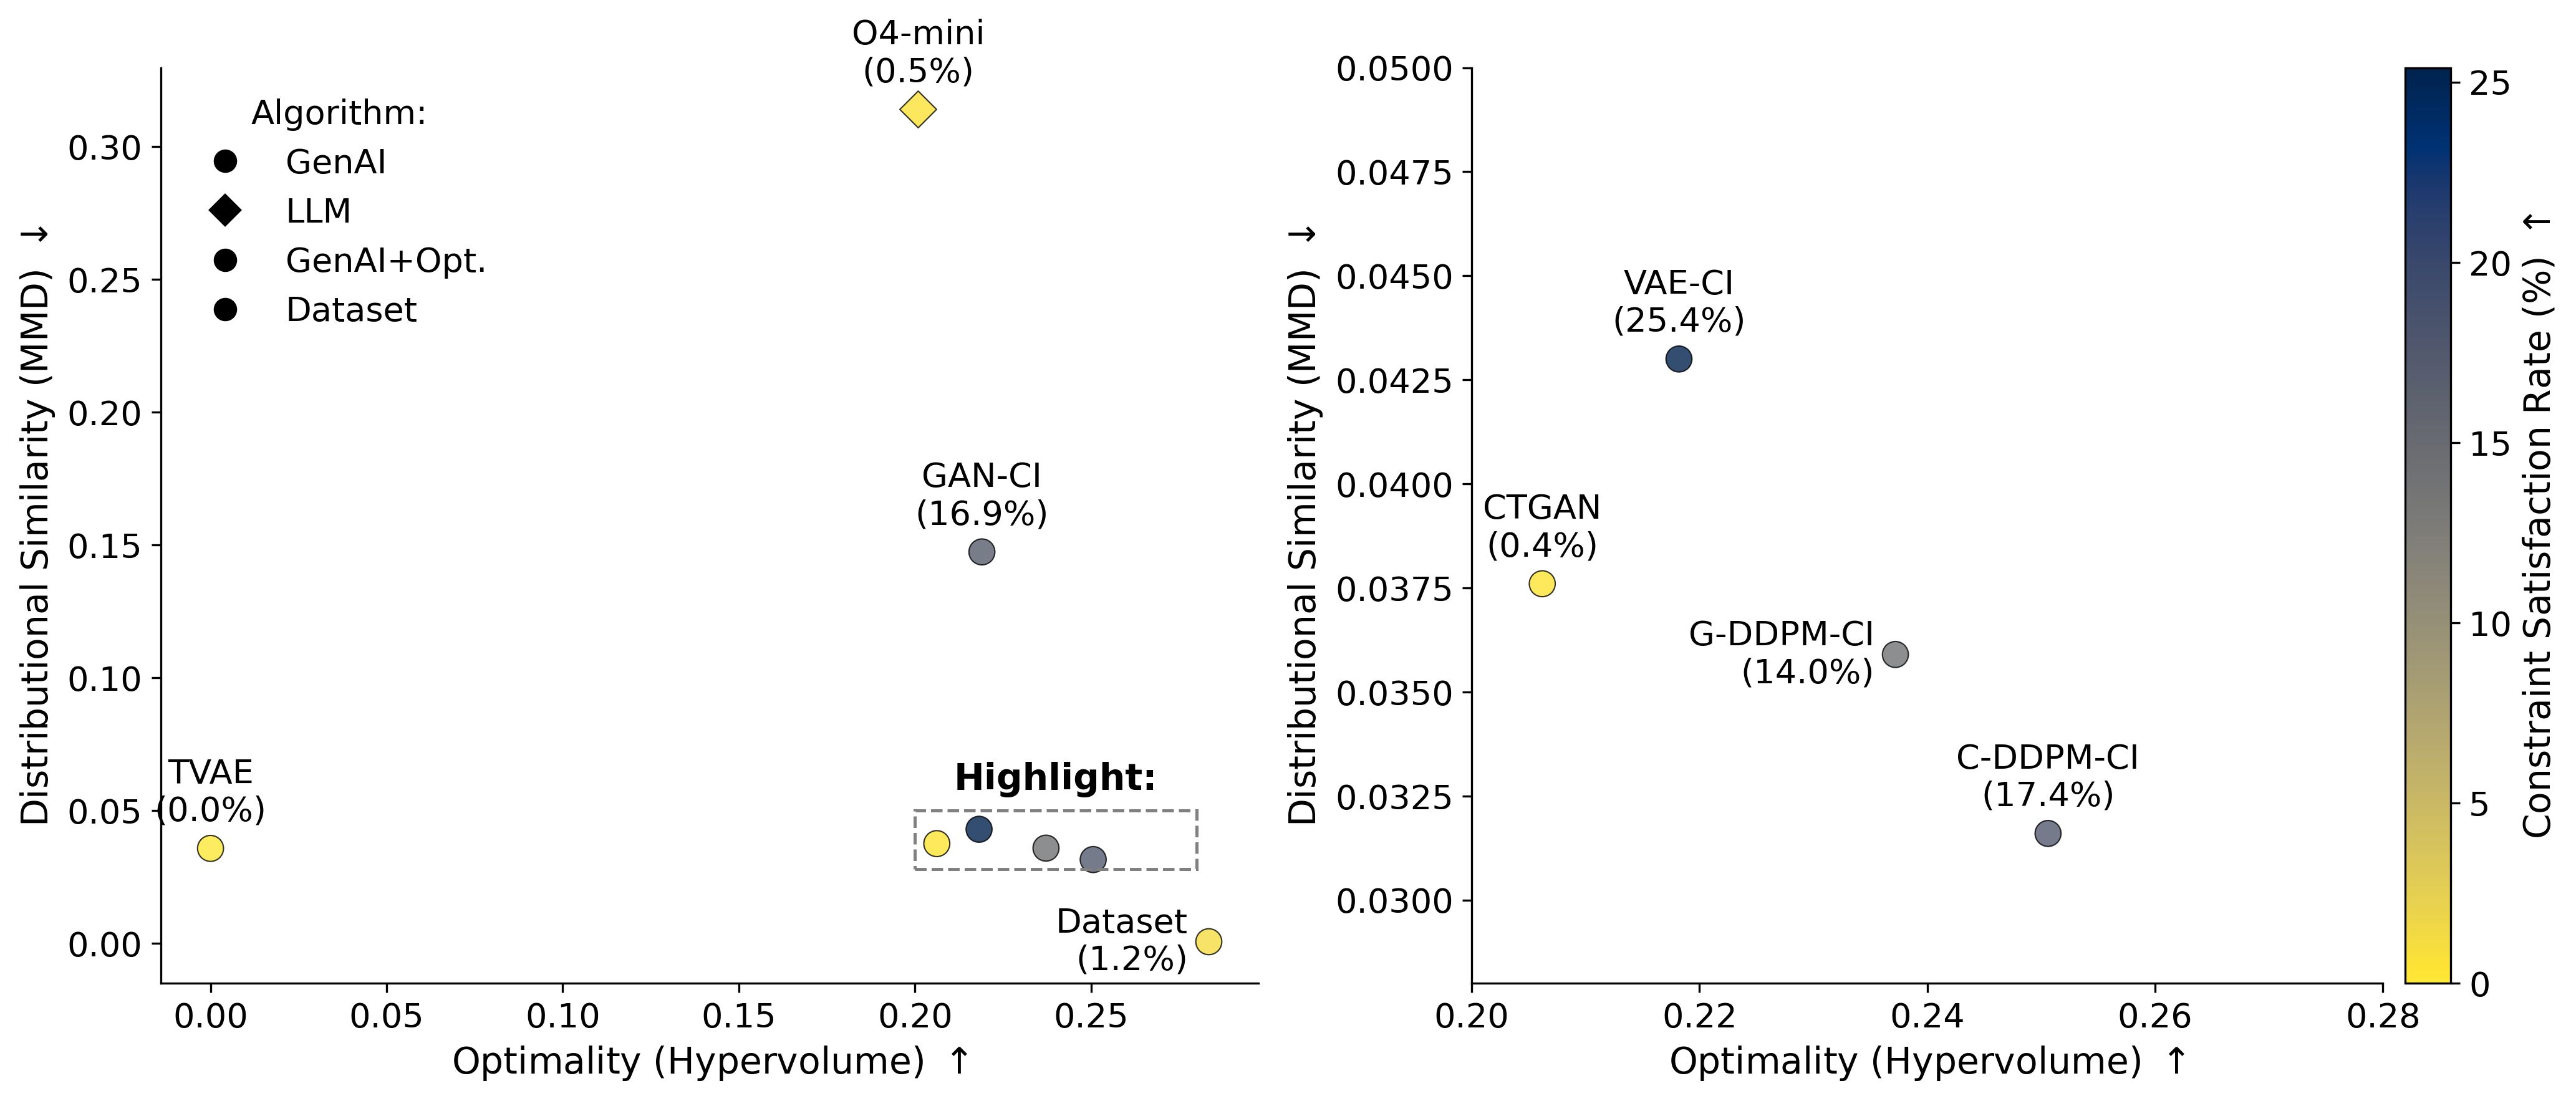

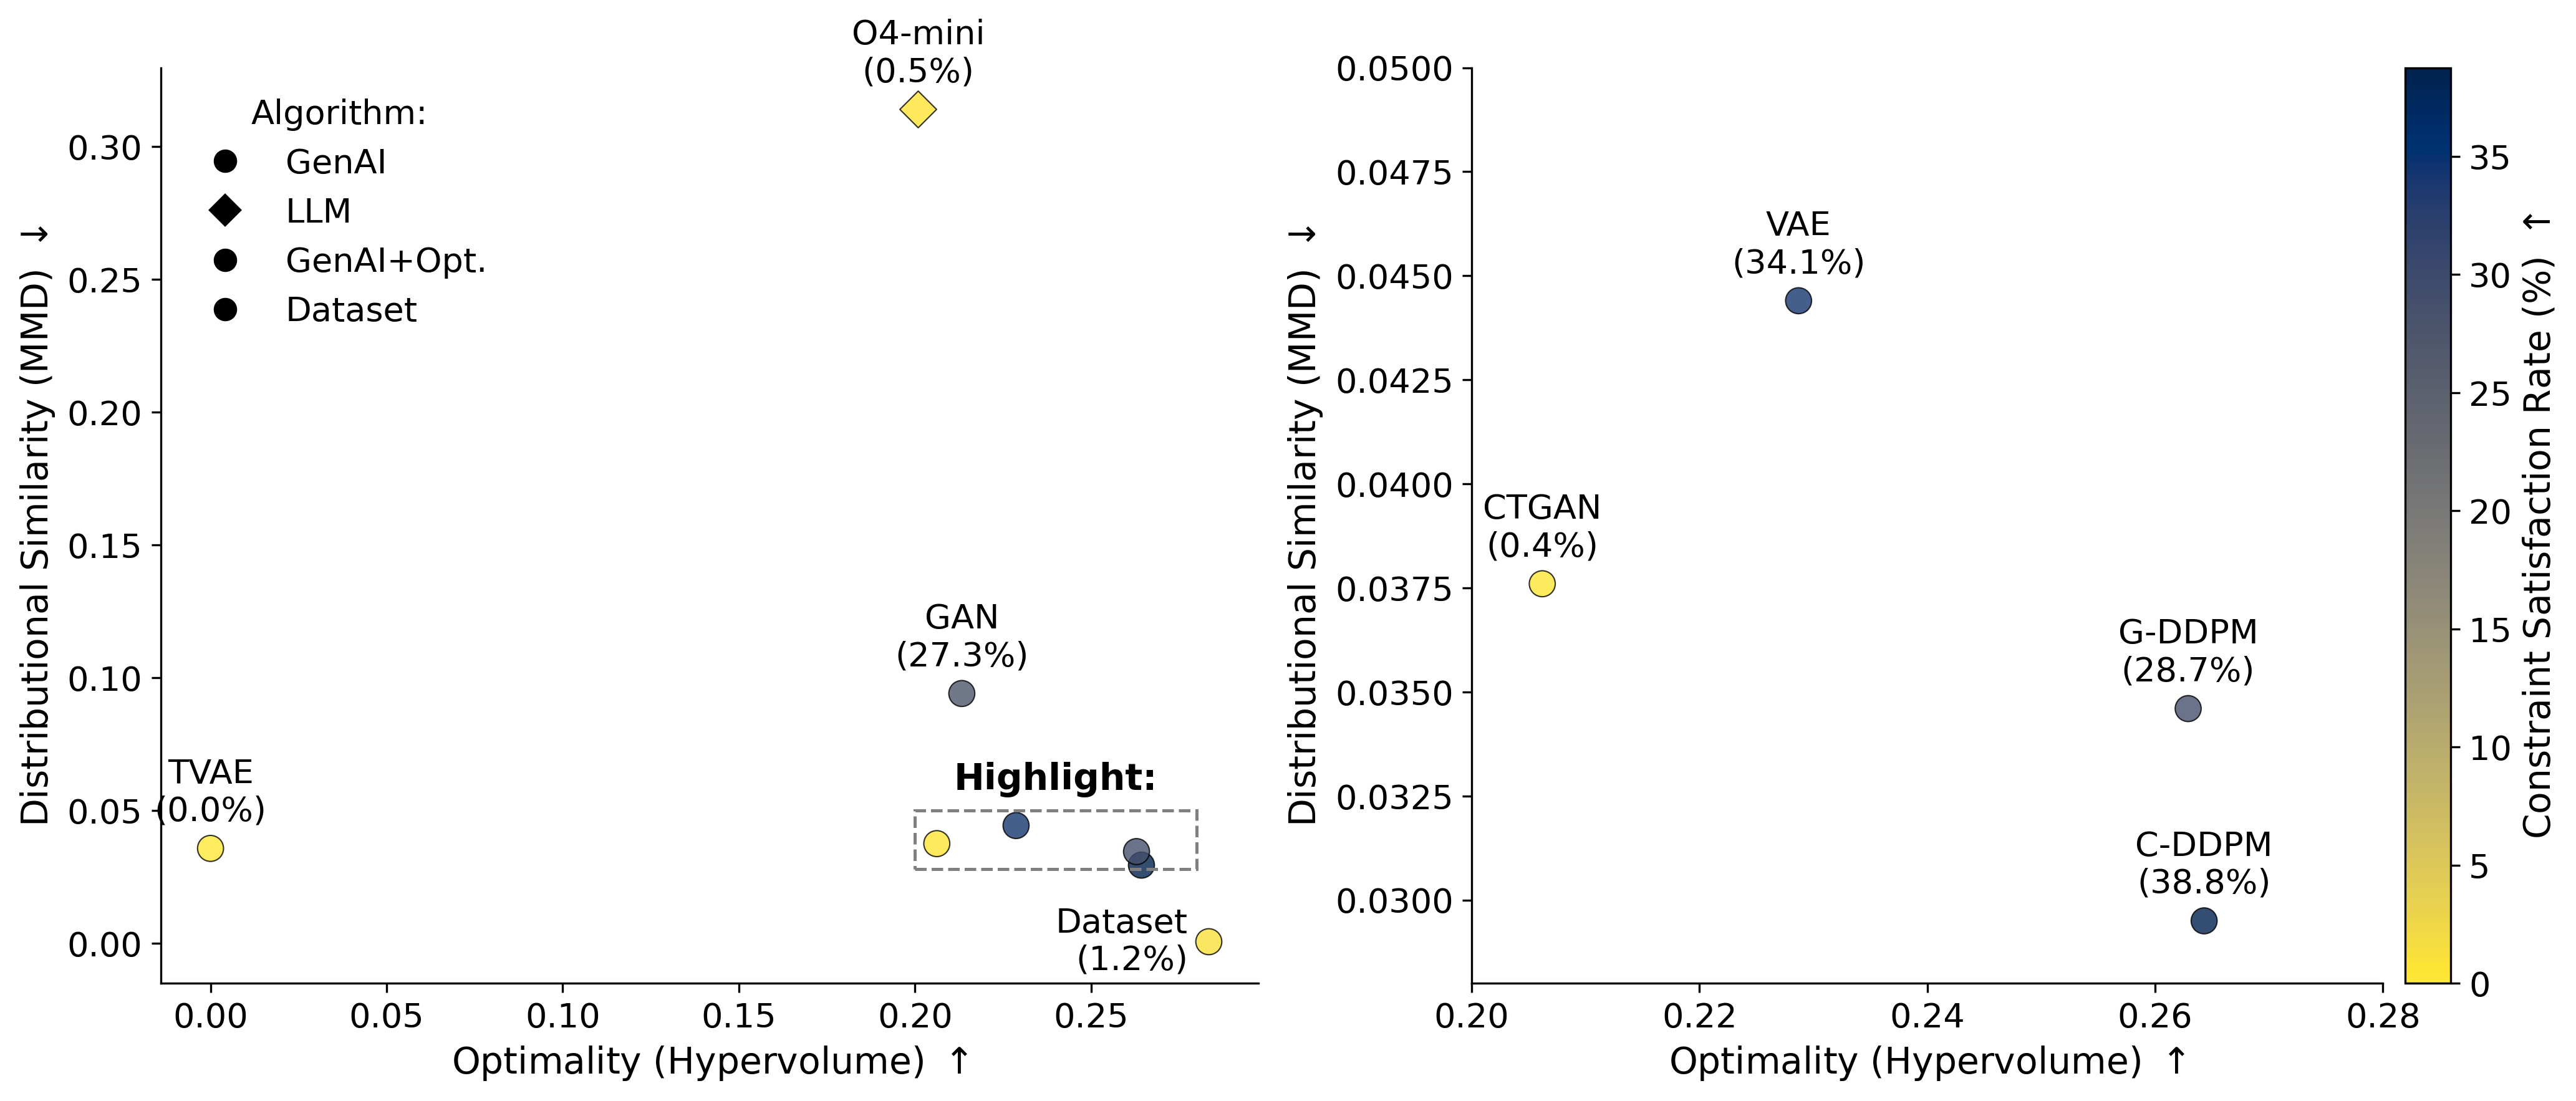

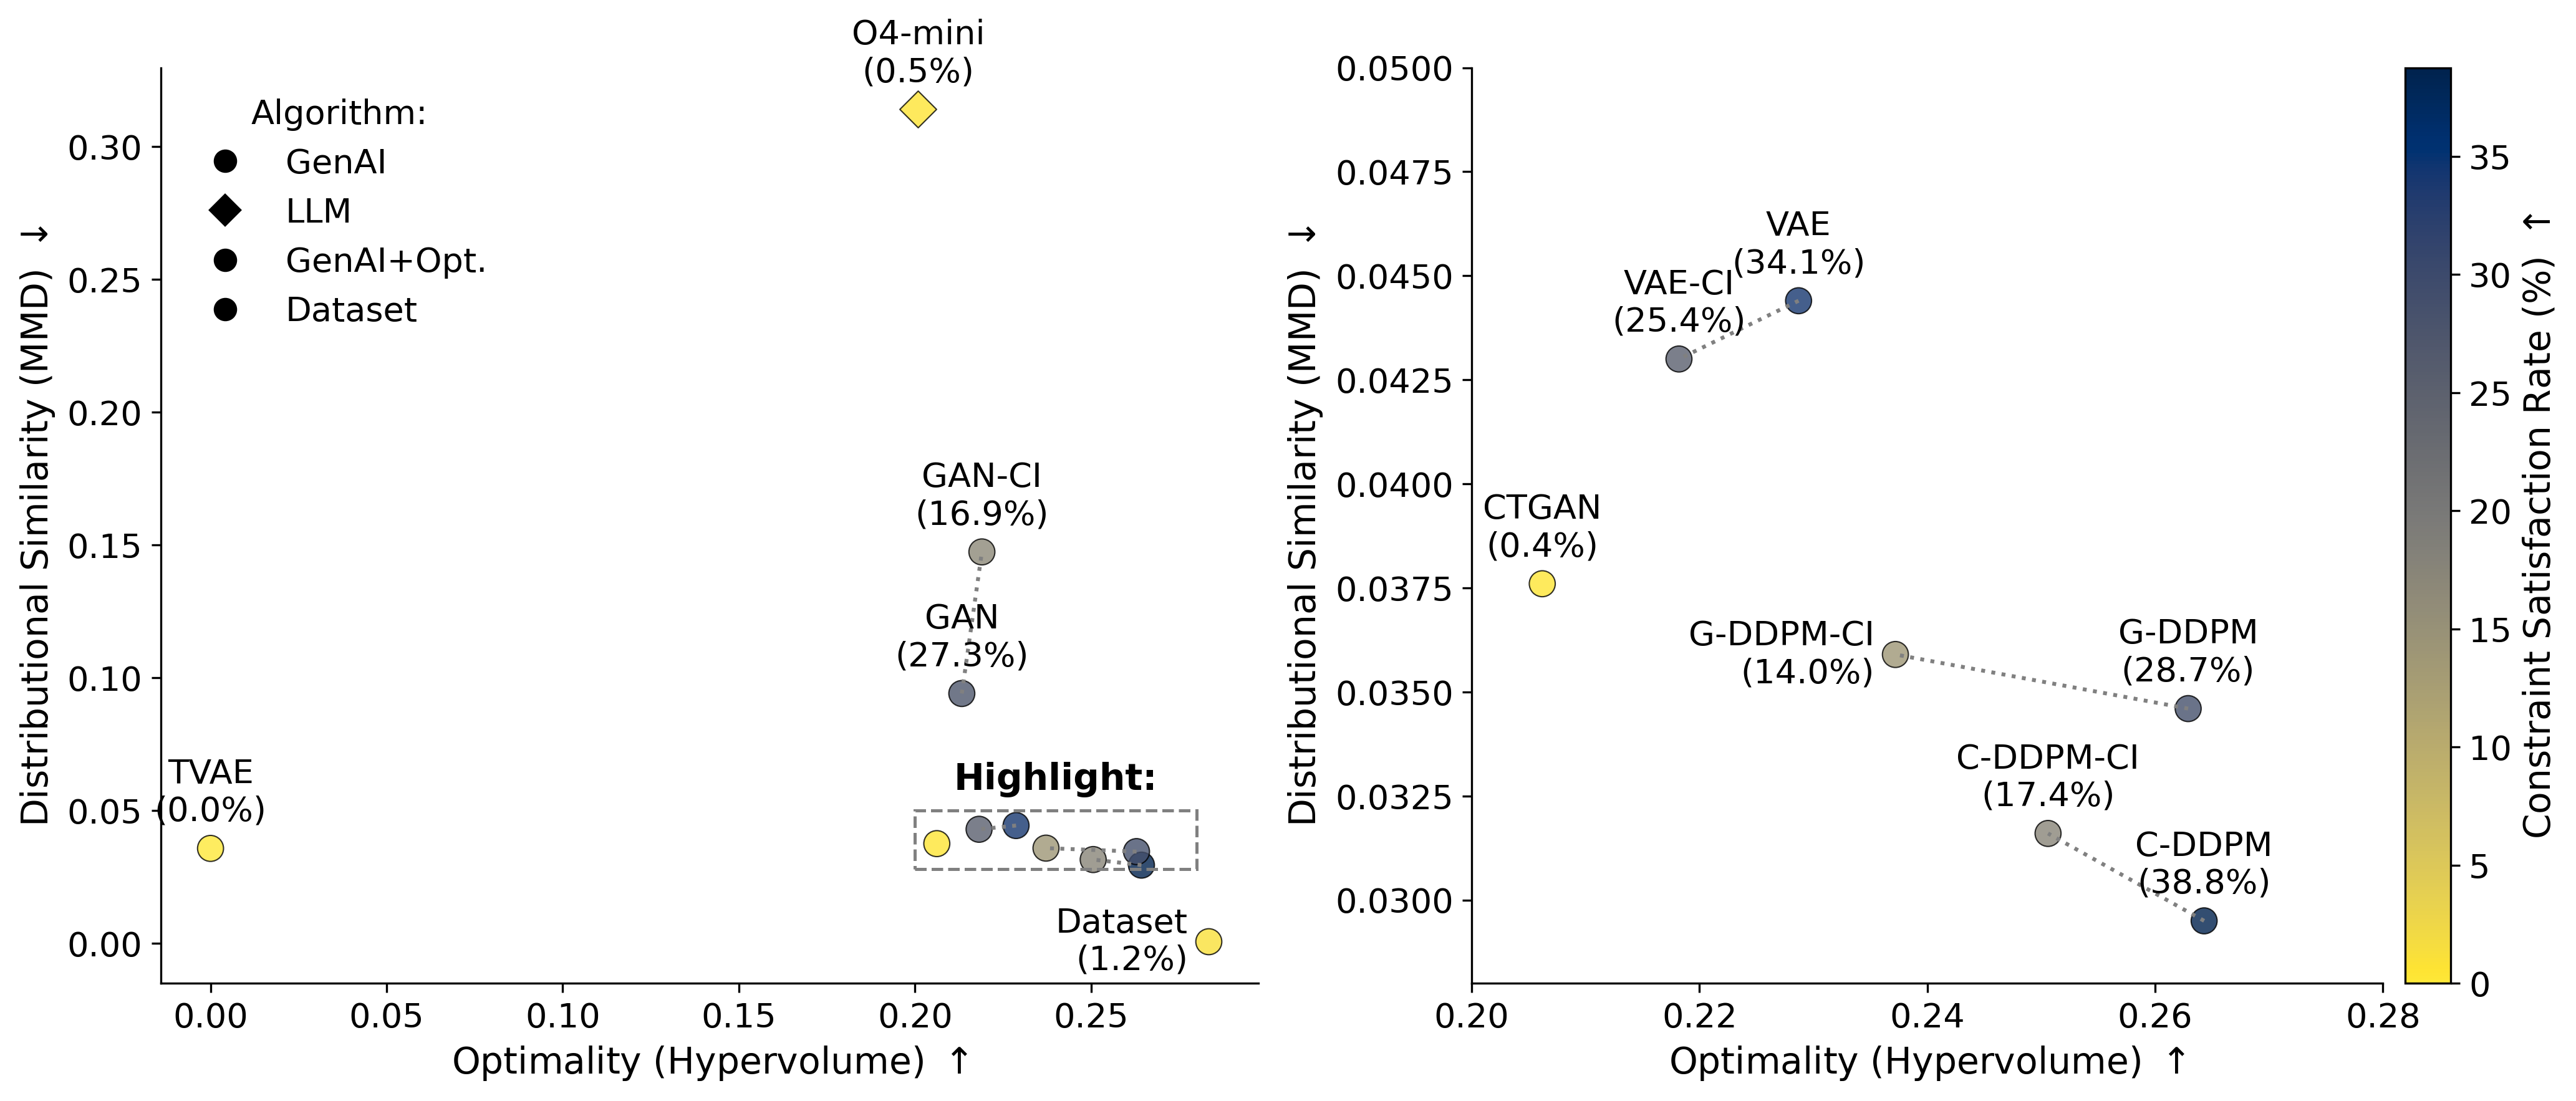

In [ ]:

rename_dict = {
"DDPM_conditional": "C-DDPM",
"DDPM_guided": "G-DDPM",
"DDPM_conditional-CI": "C-DDPM-CI",
"DDPM_guided-CI": "G-DDPM-CI",
"Agg-LS": "GD-AGG",
"Agg-LS-CI": "GD-AGG-CI",
"EPO": "GD-EPO",
"EPO-CI": "GD-EPO-CI",
}

#rename indices of classes
scores = conditional_scores.rename(index=rename_dict)

classes = ["TGM", "OAGM", "OAGM", "OAGM", "OAGM", "Data", "OAGM", "OAGM",  "LLM", "TGM", "OAGM", "OAGM"]


classes = [namedict.get(cls, cls) for cls in classes]



scores["class"] = classes



scores["annotation_location"] = "top"
scores.loc[scores.index == "GD-EPO-CI", "annotation_location"] = "left"
scores.loc[scores.index == "G-DDPM-CI", "annotation_location"] = "left"
scores.loc[scores.index == "Dataset", "annotation_location"] = "left"


plot_scores(scores, show_ci="CI", zoom_hv=(0.2, 0.28), zoom_mmd=(0.028, 0.05), legend_loc = None)  # to drop CI models
plot_scores(scores, show_ci="Base", zoom_hv=(0.2, 0.28), zoom_mmd=(0.028, 0.05), legend_loc = None)   # to include them with dotted lines
plot_scores(scores, show_ci="Both", zoom_hv=(0.2, 0.28), zoom_mmd=(0.028, 0.05), legend_loc = None)   # to include them with dotted lines

,Constraint Satisfaction Rate,Hypervolume,Maximum Mean Discrepancy,class,annotation_location
GD-AGG,93.82%,0.2817,0.5668,Optimization,top
GD-AGG-CI,6.00%,0.0759,0.5462,Optimization,top
CTGAN,0.21%,0.0630,0.0283,GenAI,top
C-DDPM,33.10%,0.1672,0.0403,GenAI+Opt.,top
C-DDPM-CI,14.84%,0.1604,0.0417,GenAI+Opt.,top
G-DDPM,30.46%,0.1697,0.0353,GenAI+Opt.,top
G-DDPM-CI,16.22%,0.1656,0.0344,GenAI+Opt.,left
GAN,33.28%,0.1324,0.1741,GenAI+Opt.,top
GAN-CI,15.68%,0.1066,0.3056,GenAI+Opt.,top
NSGA2,100.00%,0.2624,0.4813,Optimization,top


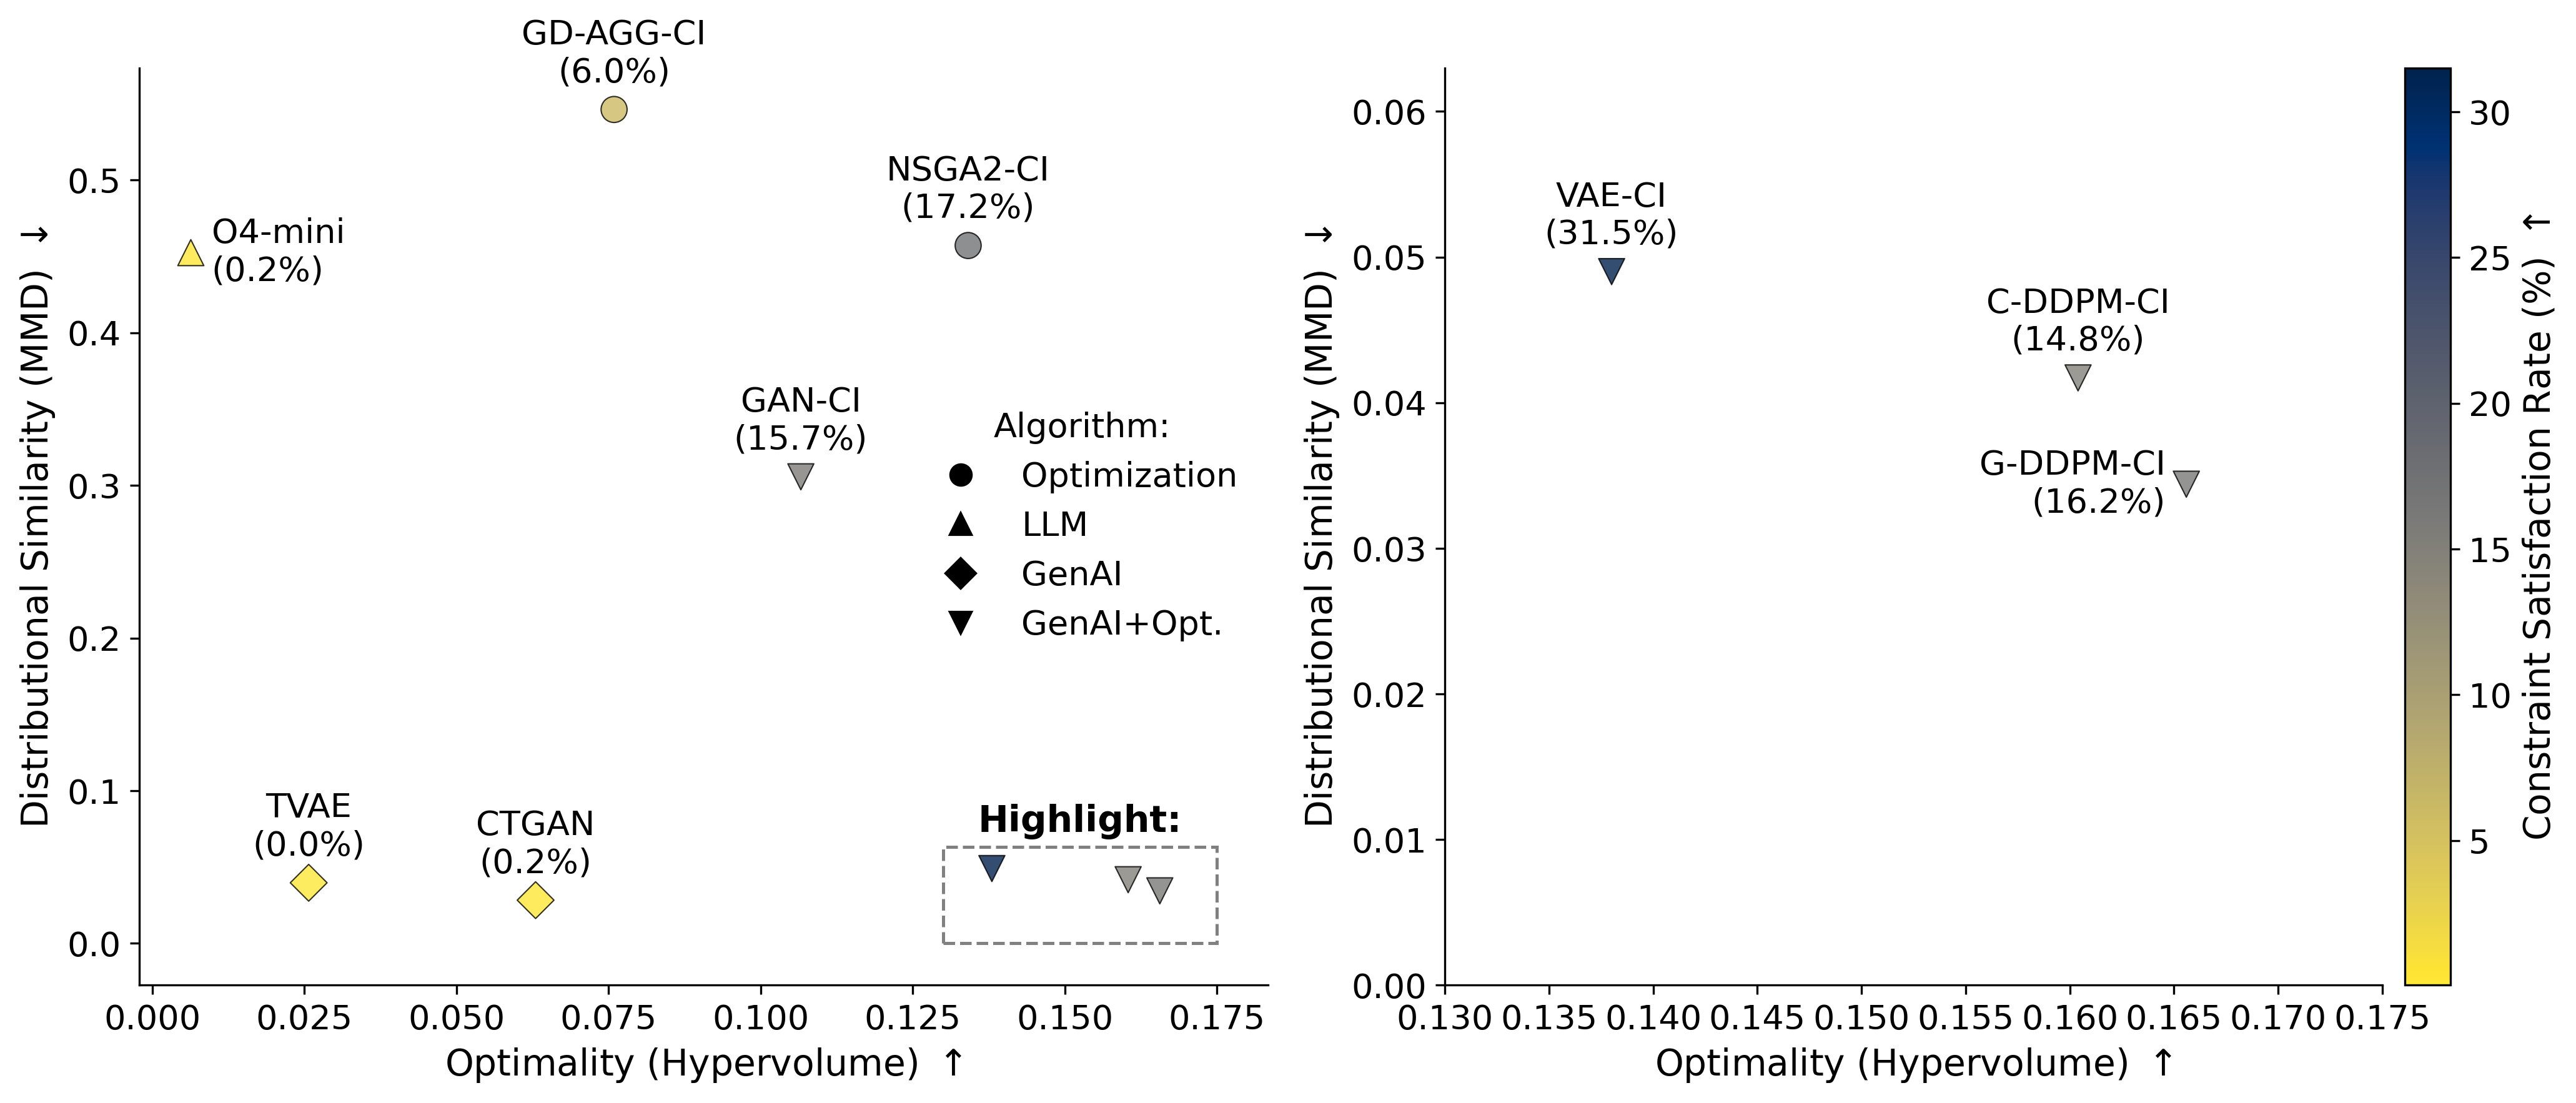

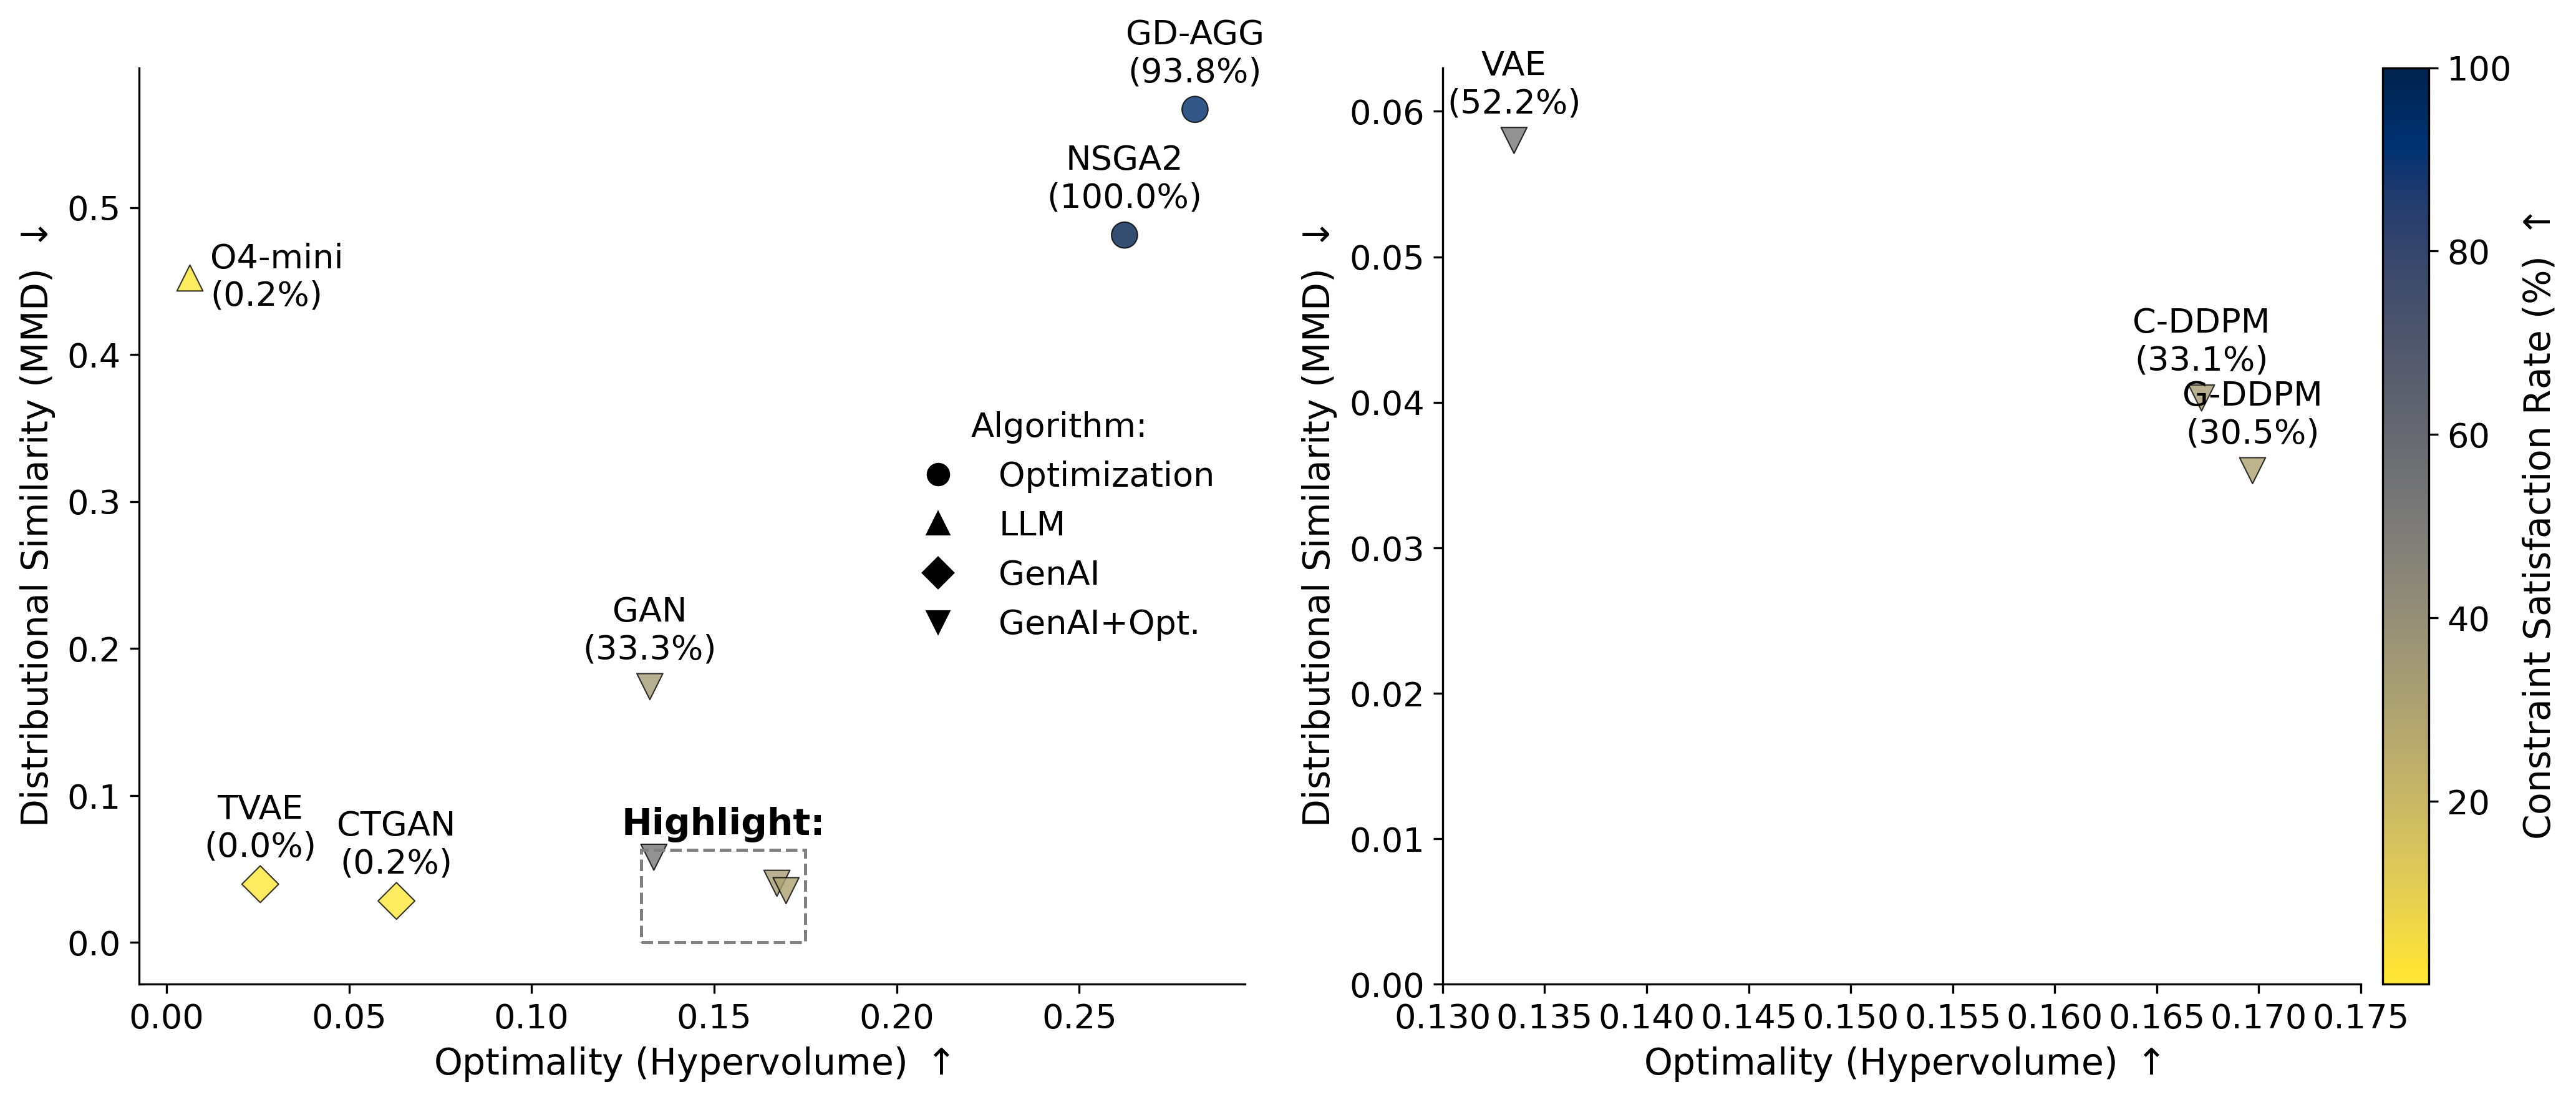

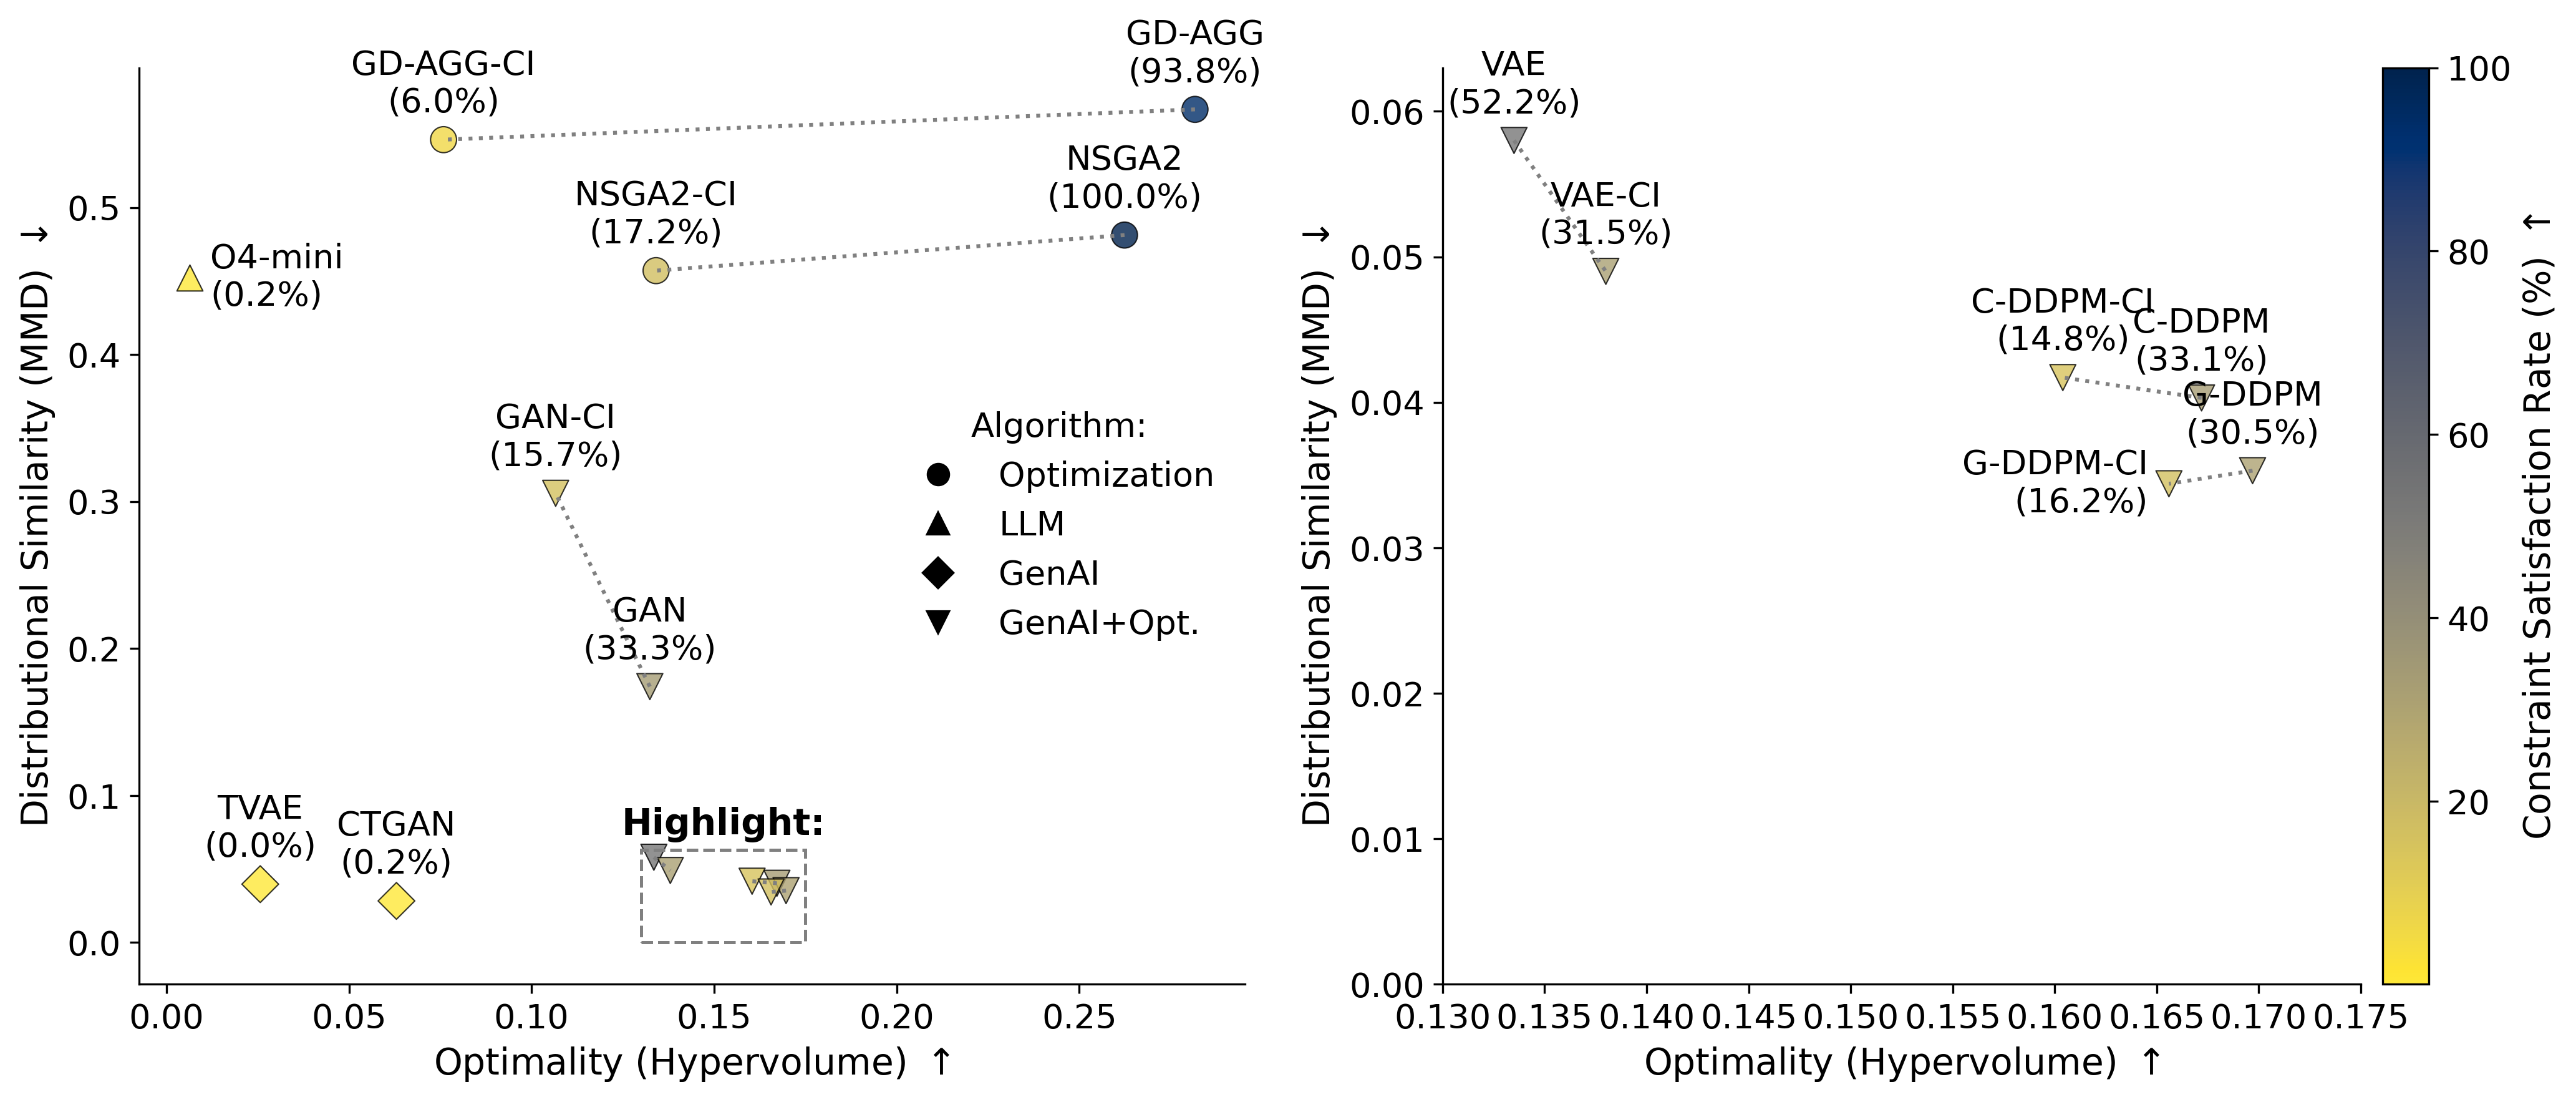

In [23]:

rename_dict = {
"DDPM_conditional": "C-DDPM",
"DDPM_guided": "G-DDPM",
"DDPM_conditional-CI": "C-DDPM-CI",
"DDPM_guided-CI": "G-DDPM-CI",
"Agg-LS": "GD-AGG",
"Agg-LS-CI": "GD-AGG-CI",
"EPO": "GD-EPO",
"EPO-CI": "GD-EPO-CI",
}

#rename indices of classes
scores = unconditional_scores.rename(index=rename_dict)

classes = ["Opt", "Opt", "TGM", "OAGM", "OAGM", "OAGM", "OAGM", "Data", "OAGM", "OAGM", "Opt", "Opt", "LLM", "TGM", "OAGM", "OAGM"]


namedict = {"Opt": "Optimization",
            "TGM": "GenAI",
            "OAGM": "GenAI+Opt.",
            "LLM": "LLM",
            "Data": "Dataset"}

classes = [namedict.get(cls, cls) for cls in classes]

scores["class"] = classes

marker_map = {"Optimization": "o",
              "GenAI": "D",
              "GenAI+Opt.": "v",
              "LLM": "^",
              "Dataset": "s"}

#drop scores that have Dataset
scores = scores[~scores.index.str.contains("Dataset")]


scores["annotation_location"] = "top"
scores.loc[scores.index == "GD-EPO-CI", "annotation_location"] = "left"
scores.loc[scores.index == "G-DDPM-CI", "annotation_location"] = "left"
# scores.loc[scores.index == "Dataset", "annotation_location"] = "left"
scores.loc[scores.index == "O4-mini", "annotation_location"] = "right"
display(scores)


plot_scores(scores, show_ci="CI", zoom_hv=(0.13, 0.175), zoom_mmd=(0.0, 0.063), marker_map=marker_map)  # to drop CI models
plot_scores(scores, show_ci="Base", zoom_hv=(0.13, 0.175), zoom_mmd=(0.0, 0.063), marker_map=marker_map)   # to include them with dotted lines
plot_scores(scores, show_ci="Both", zoom_hv=(0.13, 0.175), zoom_mmd=(0.0, 0.063), marker_map=marker_map)   # to include them with dotted lines

Compare differences between models with and without constraint masking

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def draw_lineplots(
    triplets,
    lb,
    ub,
    class_map,
    color_map,
    scaling="linear",
    direction="min",
    metric_name=""
):
    number = len(triplets) + 1

    if scaling == "linear":
        plot_range = ub - lb
    else:
        plot_range = np.log(ub) - np.log(lb)

    fig, axes = plt.subplots(number, 1, figsize=(7, 0.3*number + 1), dpi=300)
    arrowheight = 0.15

    for i in range(number):
        ax = axes[i]
        if i < number - 1:
            name, start, finish = triplets[i]

            # lookup class & color
            cls   = class_map[name]
            color = color_map.get(cls, "gray")

            # compute head_length & text_offset as before
            if start > finish:
                delta = start - finish
            else:
                delta = finish - start

            if scaling == "linear":
                base_head = 0.01 * plot_range
                text_offset = 0.01 * plot_range
            else:
                base_head = 0.01 * plot_range * (finish if start > finish else finish/(1+0.01*plot_range))
                text_offset = 0.01 * plot_range * (start if start > finish else start/(1+0.01*plot_range))

            # clamp head to 80% of delta to avoid white gap
            head_length = min(base_head, delta * 0.8)

            # draw arrow or tick
            if start > finish:
                adjusted_start = max(start, finish + head_length)
                ax.arrow(
                    adjusted_start, arrowheight,
                    finish - adjusted_start, 0,
                    width=0.06, head_width=0.2, head_length=head_length,
                    fc=color, ec=color, length_includes_head=True
                )
                ax.text(adjusted_start + text_offset, 0.03,
                        f"{(start - finish):.2f}", fontsize=12,
                        ha='left')
            elif start < finish:
                adjusted_start = min(start, finish - head_length)
                ax.arrow(
                    adjusted_start, arrowheight,
                    finish - adjusted_start, 0,
                    width=0.06, head_width=0.2, head_length=head_length,
                    fc=color, ec=color, length_includes_head=True
                )
                ax.text(adjusted_start - text_offset, 0.03,
                        f"{(finish - start):.2f}", fontsize=12,
                        ha='right')
            else:
                ax.plot(start, arrowheight, marker='|', markersize=40, color=color)
                ax.text(start - text_offset, 0.03, "0.00",
                        fontsize=12, ha='right', va='bottom')

            # hide axes and label
            ax.spines['bottom'].set_color('none')
            ax.xaxis.set_major_locator(ticker.NullLocator())
            ax.get_xaxis().set_visible(False)
            ax.text(-0.01, 0.1, name, fontsize=12,
                    transform=ax.transAxes, ha='right')

        else:
            ax.xaxis.set_ticks_position('bottom')
            ax.set_xlabel(metric_name, fontsize=12)

        ax.set_xscale(scaling)
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.xaxis.get_major_formatter().set_scientific(False)
        ax.xaxis.get_major_formatter().set_useOffset(False)
        ax.spines['left'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.spines['right'].set_color('none')
        ax.yaxis.set_major_locator(ticker.NullLocator())
        ax.set_xlim(lb, ub)
        ax.set_ylim(0, 0.3)
        ax.patch.set_alpha(0.0)

    plt.tight_layout()
    plt.show()


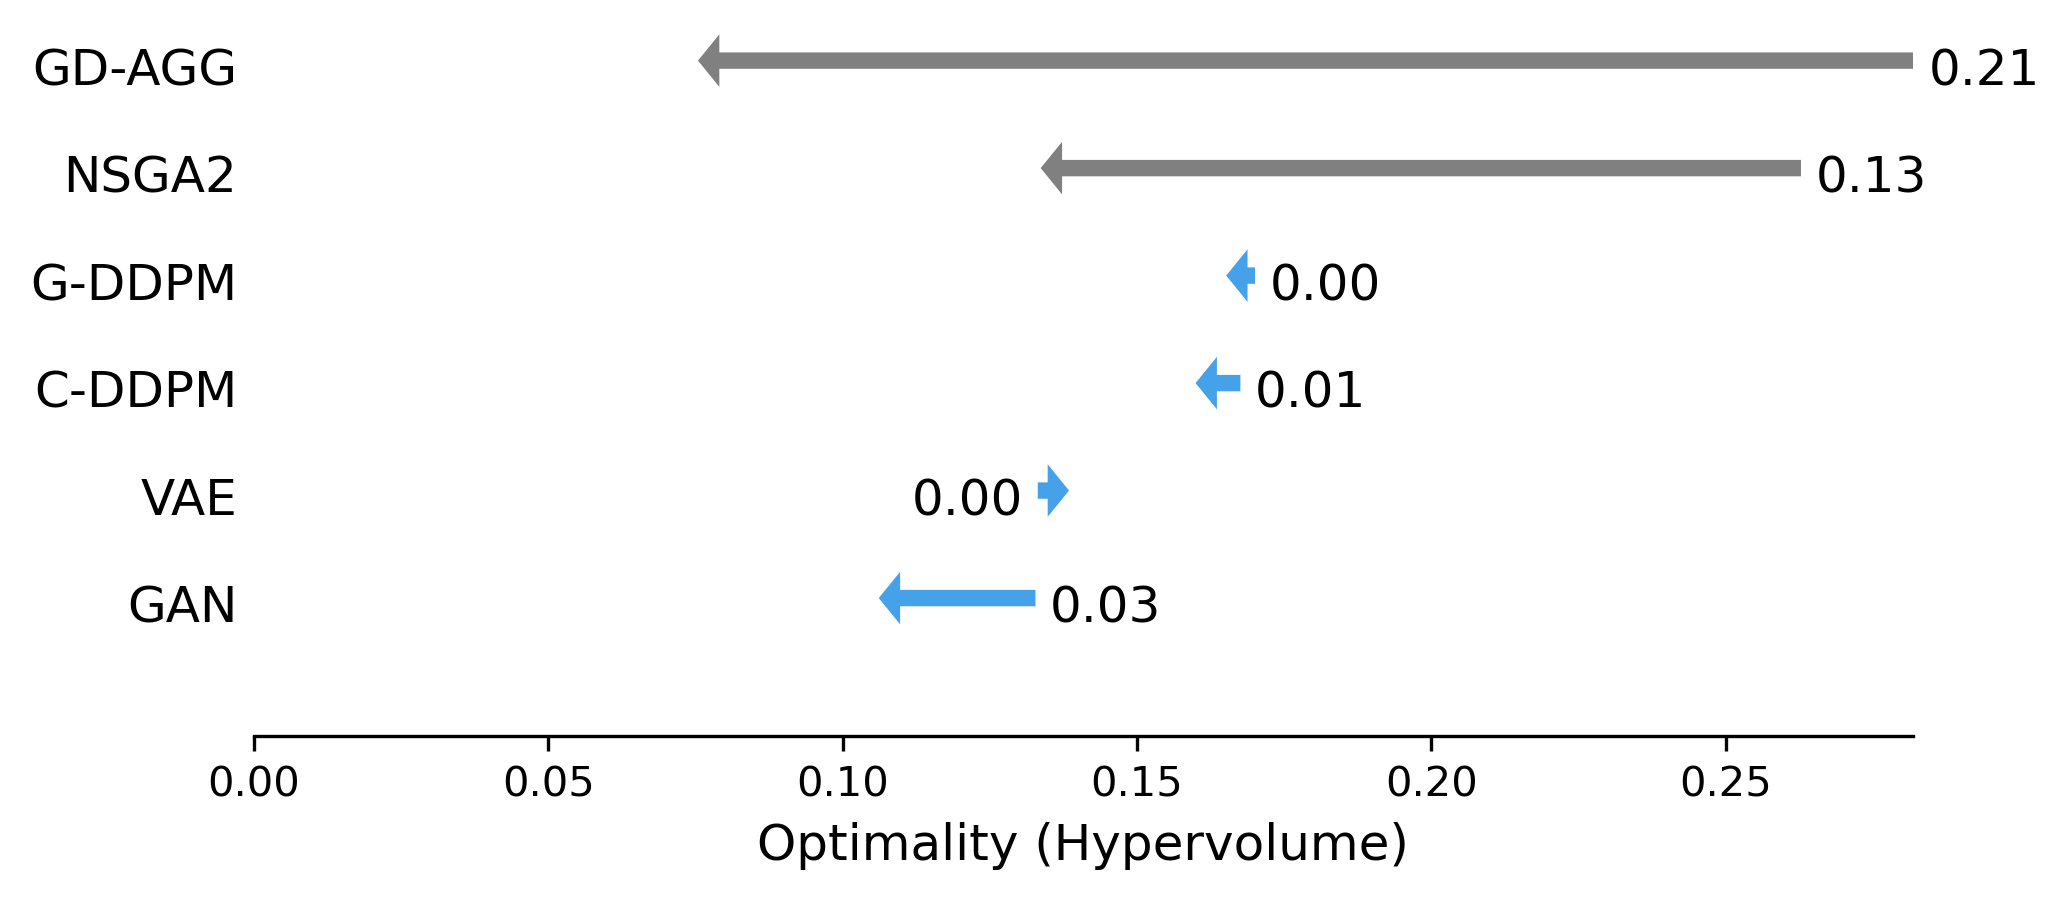

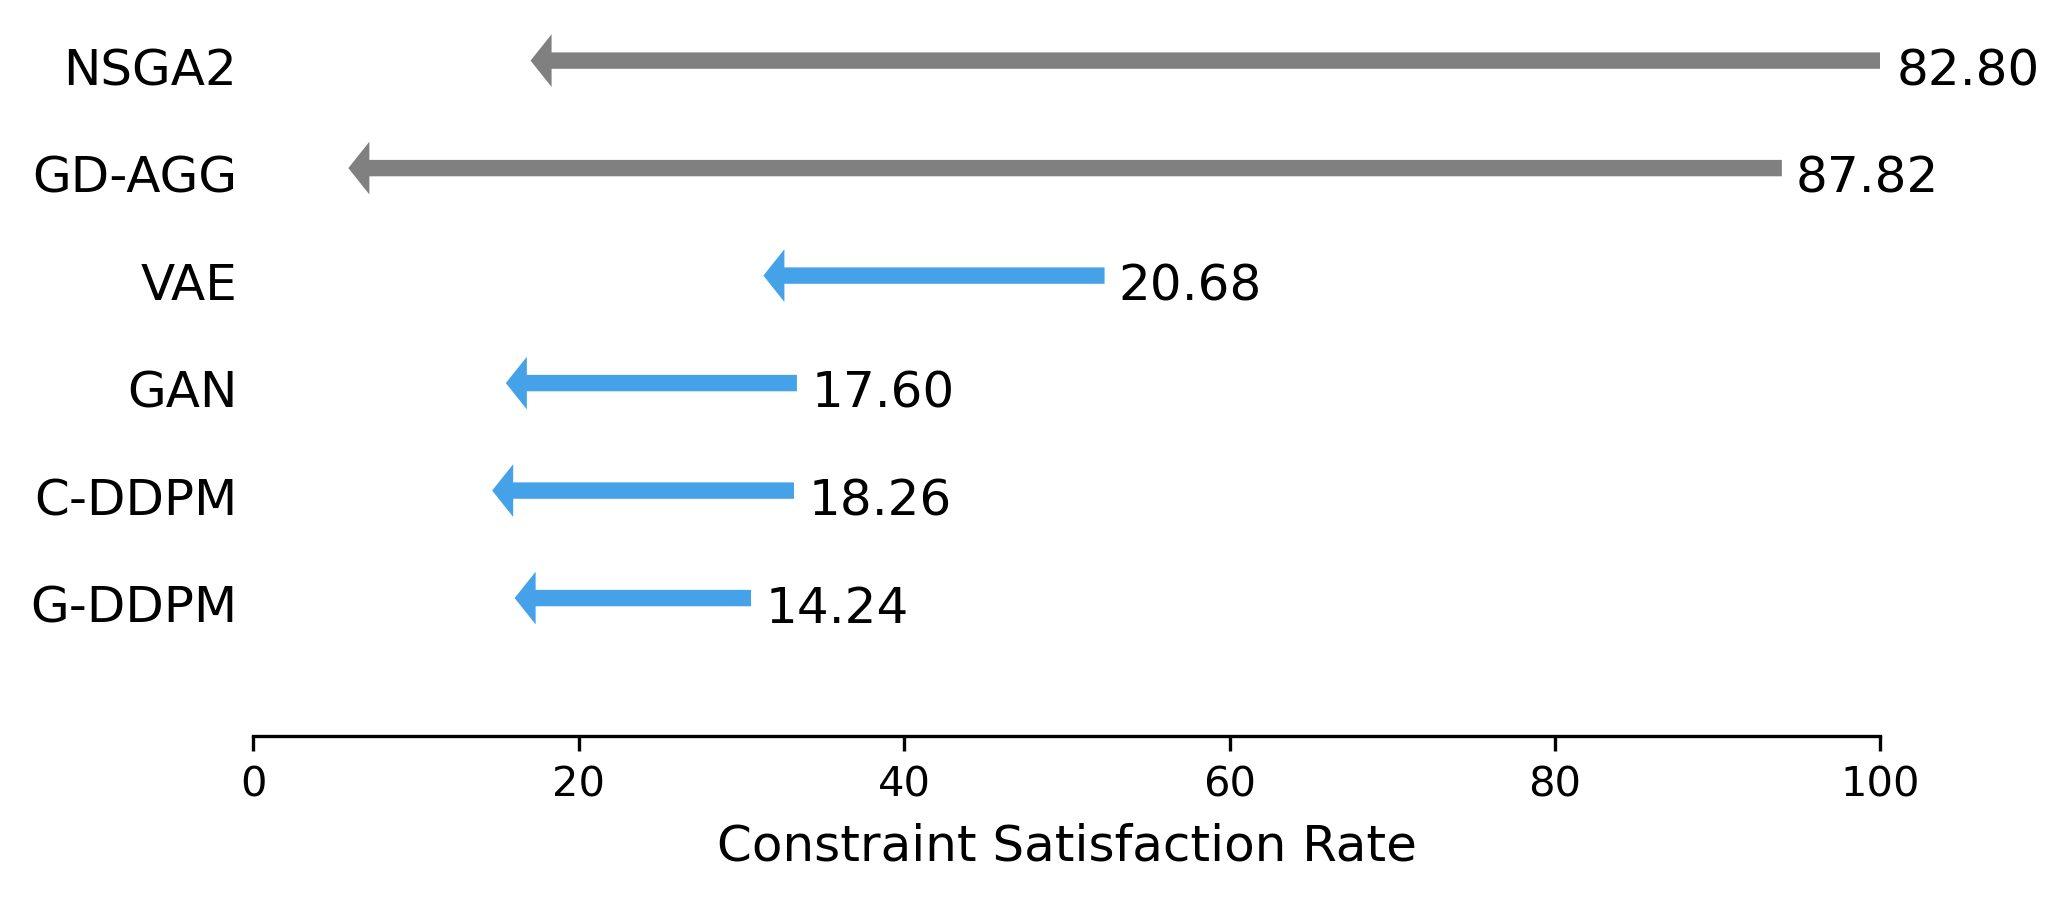

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def prepare_ci_triplets(df, metric_col):
    """
    Given a DataFrame df indexed by model name with column metric_col,
    returns a list of (base_name, non_ci_value, ci_value) for every
    model ending in '-CI' that has a corresponding base_name.
    """
    # if the column is CSR percentages, convert
    if df[metric_col].dtype == object and df[metric_col].str.endswith('%').all():
        vals = df[metric_col].str.rstrip('%').astype(float)
    else:
        vals = df[metric_col].astype(float)

    triplets = []
    for model in df.index:
        if model.endswith('-CI'):
            base = model[:-3]
            if base in df.index:
                start = vals.at[base]
                finish = vals.at[model]
                triplets.append((base, start, finish))

    triplets.sort(key=lambda x: x[1], reverse=True)
    return triplets


metric = "Hypervolume" 

triplets = prepare_ci_triplets(scores, metric)


all_vals = [v for _, s, f in triplets for v in (s, f)]
lb, ub = 0, max(all_vals)

class_map = scores['class'].to_dict()
color_map = {
    "Opt":    "gray",  # blue
    "OAGM":   "#46a2e8",  # purple
}

draw_lineplots(
    triplets,
    lb, ub,
    class_map=class_map,
    color_map=color_map,
    scaling="linear",
    metric_name="Optimality (Hypervolume)",
    # decimal_places=3
)

metric = "Constraint Satisfaction Rate" 

triplets = prepare_ci_triplets(scores, metric)


all_vals = [v for _, s, f in triplets for v in (s, f)]
lb, ub = 0, 100

draw_lineplots(
    triplets,
    lb, ub,
    class_map=class_map,
    color_map=color_map,
    scaling="linear",
    metric_name="Constraint Satisfaction Rate",
    # decimal_places=1
)





## Scorecards

In [10]:
def create_scorecards_conditional(device="cuda"):

    data = data_loading.load_bike_bench_train()
    all_result_tens = []
    result_dir = os.path.join("results", "conditional")
    all_names = os.listdir(result_dir)
    for name in all_names:
        if os.path.isdir(os.path.join(result_dir, name)):
            result_tens = torch.load(os.path.join(result_dir, name, "result_tens.pt"))
            all_result_tens.append(result_tens)
    num_samples=10000
    split = "test"
    randomize = False
    emb = conditioning.sample_image_embedding(num_samples, split, randomize)
    rider = conditioning.sample_riders(num_samples, split, randomize)
    use_case = conditioning.sample_use_case(num_samples, split, randomize)
    condition = {"Rider": rider, "Use Case": use_case, "Embedding": emb}

    dashboard = ScoreReportDashboard(
    design_batches   = all_result_tens,
    eval_funcs       = get_standard_evaluations(device),
    model_names      = all_names,
    condition        = condition,
    column_names     = data.columns.tolist(),
    device           = device
    )

    for name in all_names:
        dashboard.show_model(name)
    
create_scorecards_conditional(device="cpu")

c:\Users\Lyler\Documents\Bike-Bench-Temporary\src\biked_commons\benchmark_models\../..\biked_commons\design_evaluation\score_report.py:99: UserWarning: No model_colors provided; using Matplotlib cycle.
  warnings.warn("No model_colors provided; using Matplotlib cycle.")


KeyboardInterrupt: 

Plot unconditional score cards for the first condition index

c:\Users\Lyler\Documents\Repositories\Bike-Bench-Temporary\src\biked_commons\benchmark_models\../..\biked_commons\design_evaluation\score_report.py:99: UserWarning: No model_colors provided; using Matplotlib cycle.
  warnings.warn("No model_colors provided; using Matplotlib cycle.")


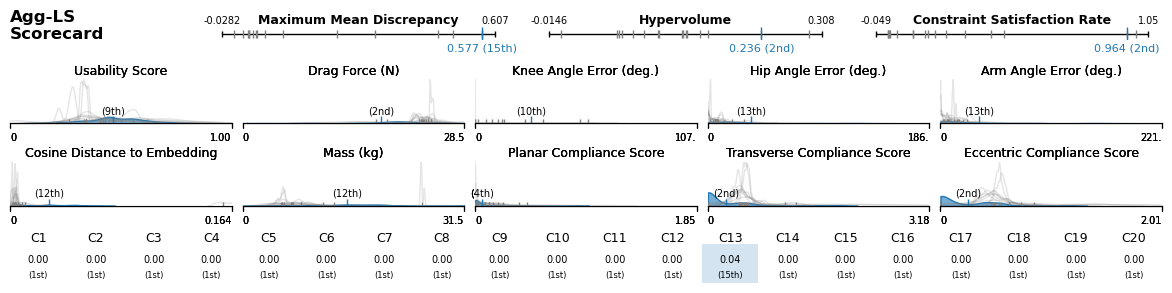

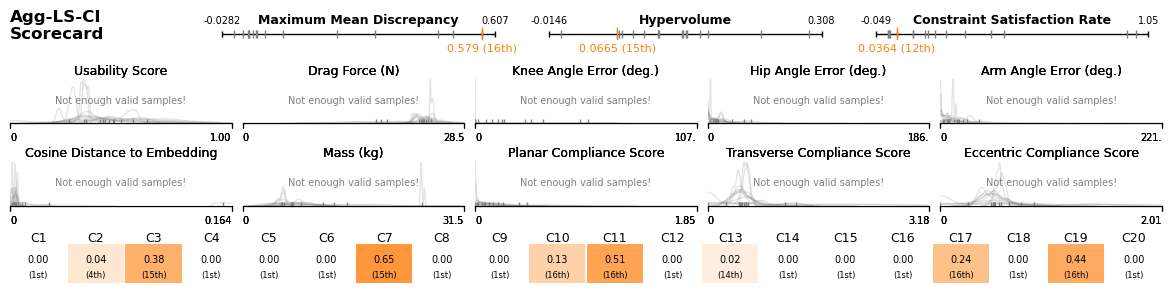

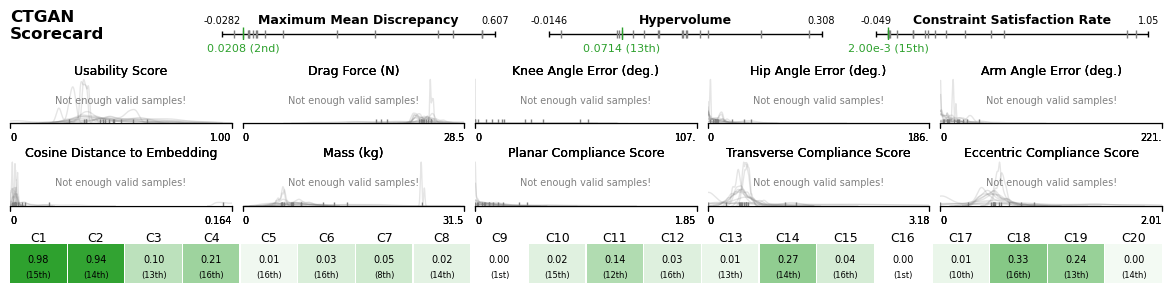

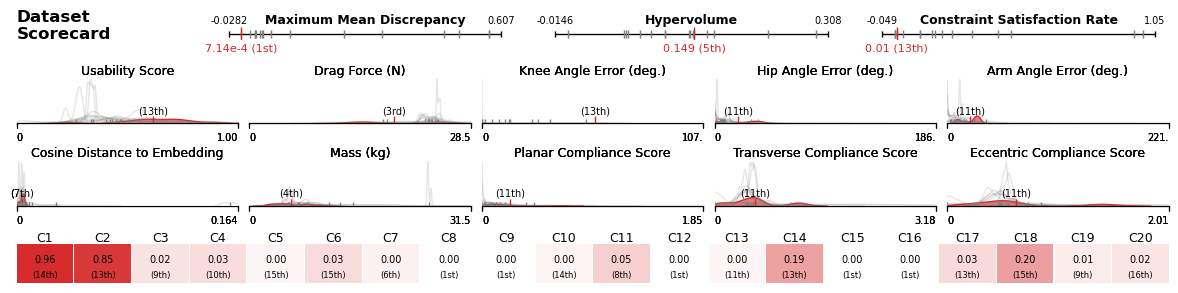

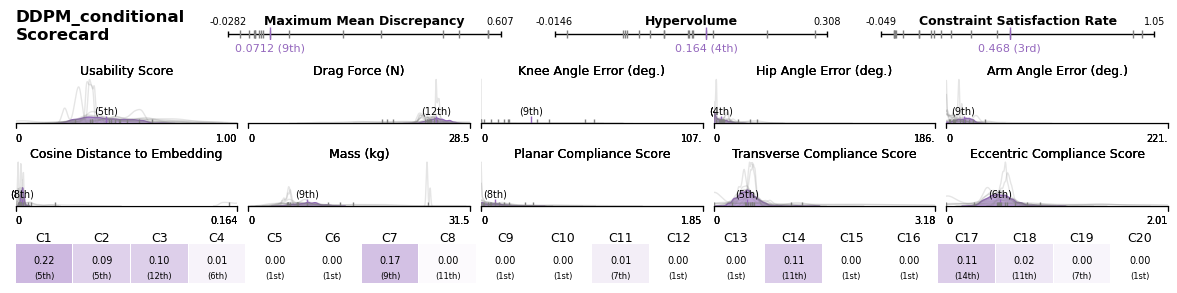

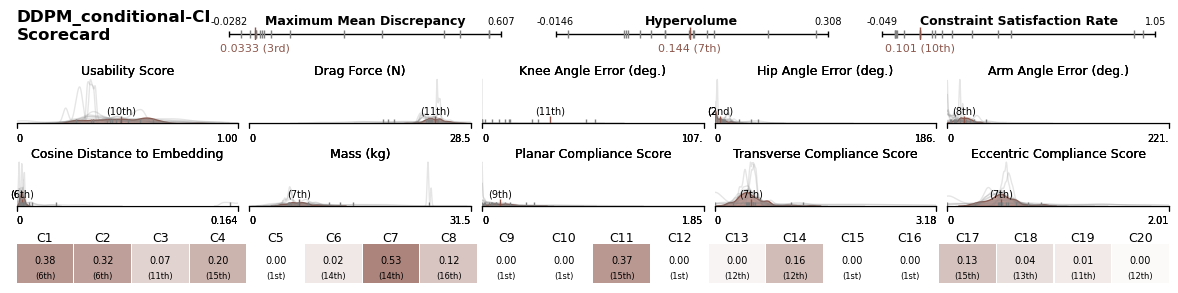

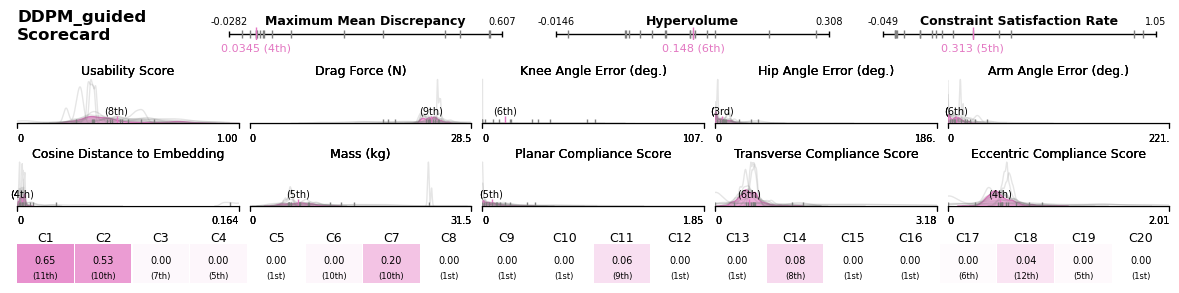

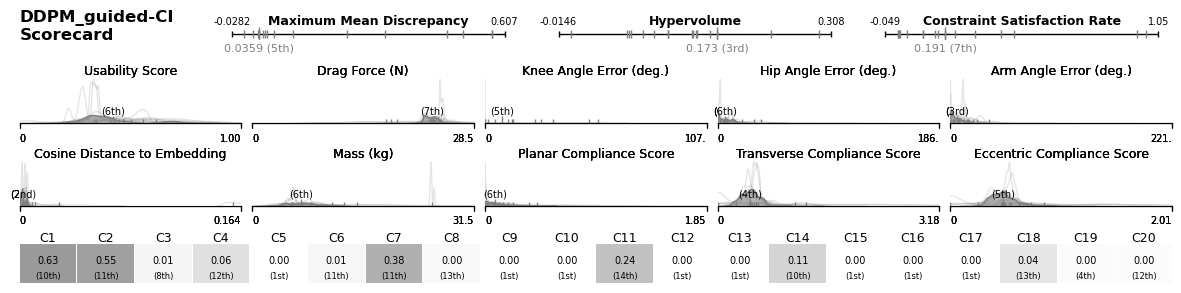

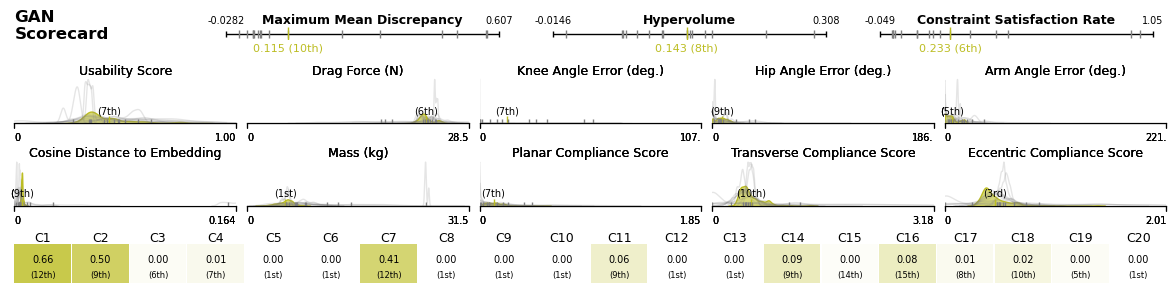

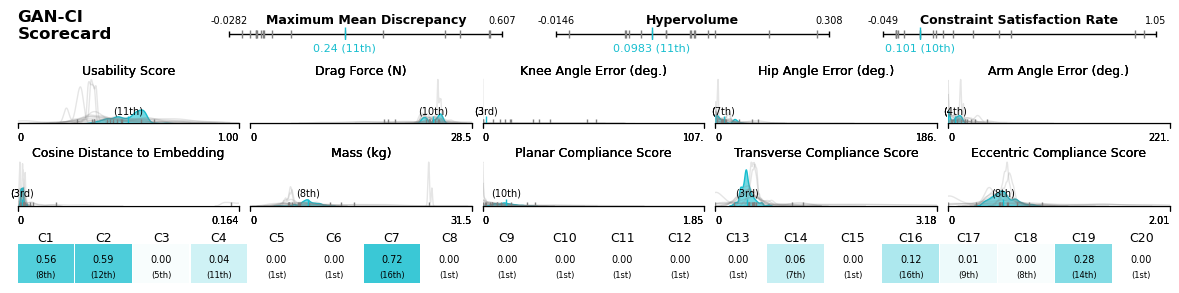

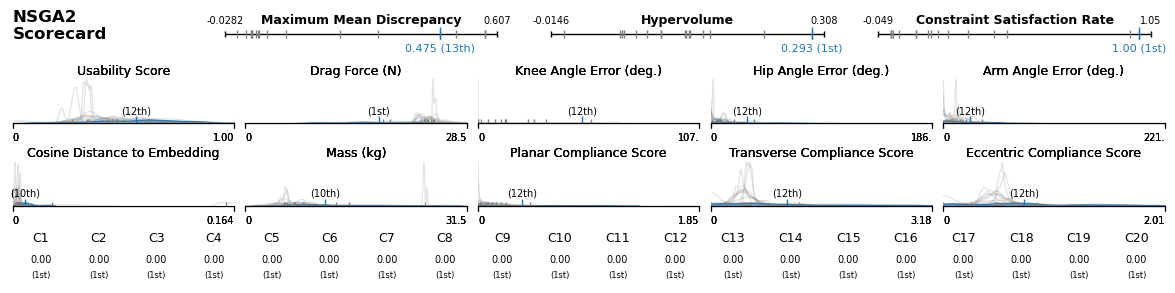

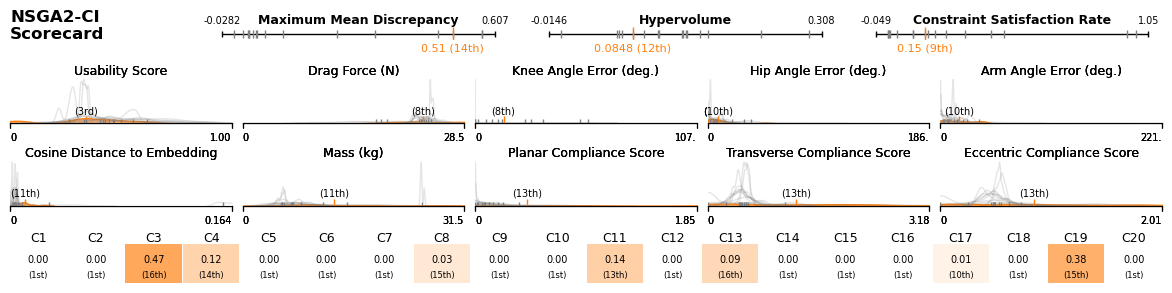

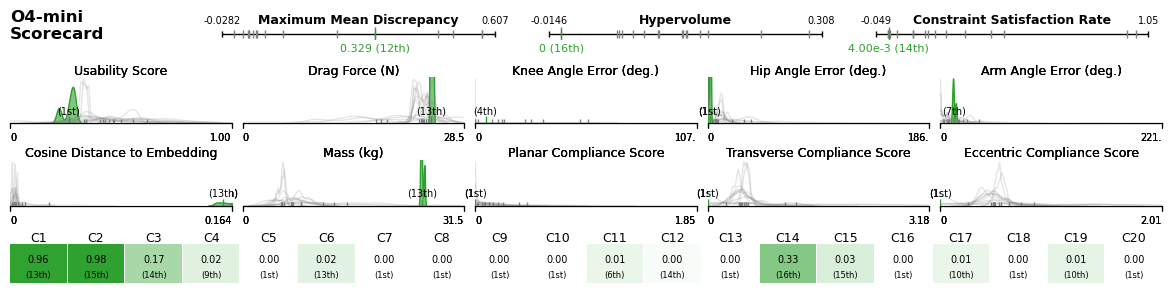

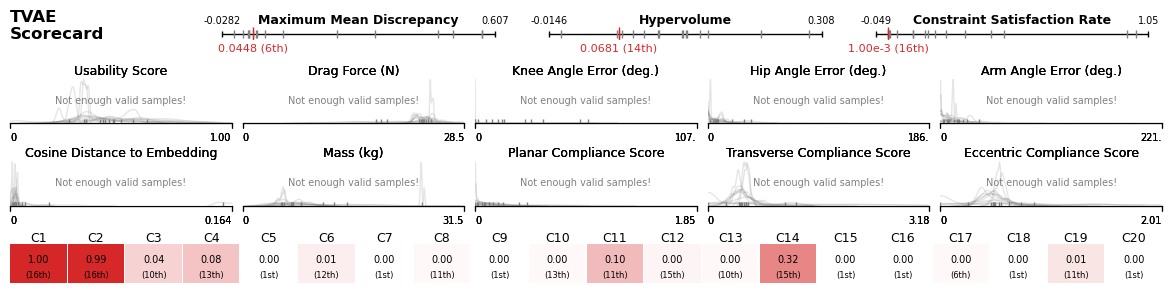

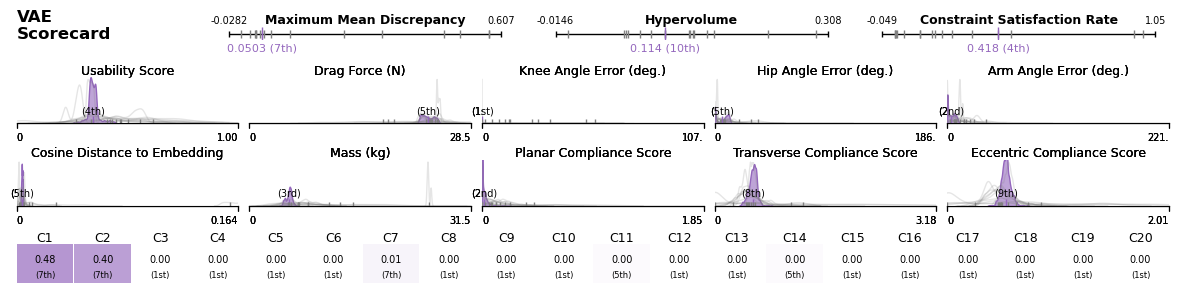

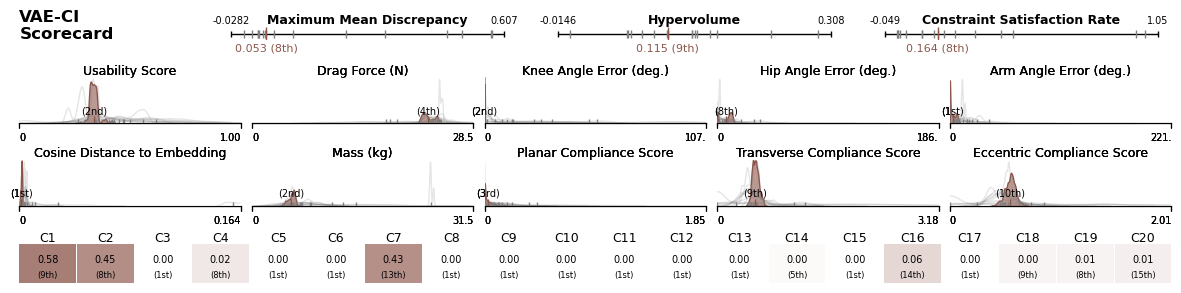

In [ ]:
def create_scorecards_unconditional(device="cuda", cond_idx=0):

    data = data_loading.load_bike_bench_train()
    all_result_tens = []
    result_dir = os.path.join("results", "unconditional", f"cond_{cond_idx}")
    all_names = os.listdir(result_dir)
    for idx, name in enumerate(all_names):
        if os.path.isdir(os.path.join(result_dir, name)):
            result_tens = torch.load(os.path.join(result_dir, name, "result_tens.pt"))
            all_result_tens.append(result_tens)


    num_samples=10
    split = "test"
    randomize = False
    emb = conditioning.sample_image_embedding(num_samples, split, randomize)
    rider = conditioning.sample_riders(num_samples, split, randomize)
    use_case = conditioning.sample_use_case(num_samples, split, randomize)
    condition = {"Rider": rider[cond_idx], "Use Case": use_case[cond_idx], "Embedding": emb[cond_idx]}

    
    dashboard = ScoreReportDashboard(
        design_batches   = all_result_tens,
        eval_funcs       = get_standard_evaluations(device),
        model_names      = all_names,
        condition        = condition,
        column_names     = data.columns.tolist(),
        device           = device,
    )

    for name in all_names:
        dashboard.show_model(name, truncate_tails_magnitude=0.0)
    
create_scorecards_unconditional(device="cuda")